In [1]:
import numpy as np
import matplotlib.pyplot as plt

#  Thermisches Rauschen eines Widerstands

Die Rauschspannung eines Widerstands sei normalverteilt:

$$ V \sim \mathcal{N}(0,\sigma)$$

mit $\sigma = 2\,\text{mV}$.


- Simulieren Sie $10^5$ Spannungswerte.
- Bestimmen Sie die Wahrscheinlichkeit $|V| > 5\,\text{mV}.$
- Bestimmen Sie Erwartungswert und Varianz aus der Simulation.
- Plotten Sie das Histogramm und die theoretische Normalverteilung.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

Die Simulierte Wahrscheinlichkeit von |V|>5mV beträgt: 6.030000000e-03
Erwartungswert: 4.153417081e-06
Varianz: 3.986523542e-06


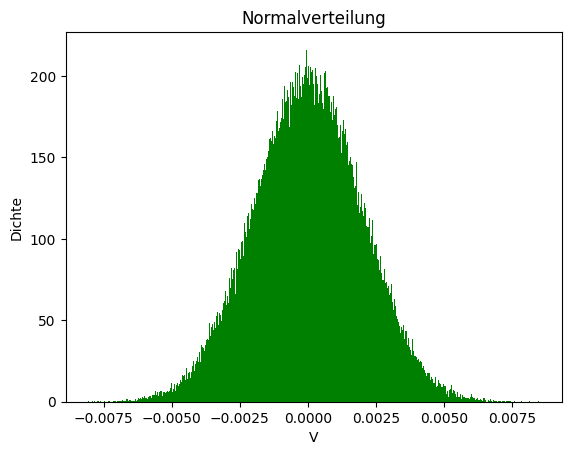

In [117]:
size = 10**5
sigma = 0.002

data = np.random.normal(0, sigma, size)
data_reduced = np.mean(data>0.005)
print(f'Die Simulierte Wahrscheinlichkeit von |V|>5mV beträgt: {data_reduced:.9e}')

#Erwartungswert und Varianz aus der Simulation
mean = np.mean(data)
variance = np.var(data)
print(f'Erwartungswert: {mean:.9e}')
print(f'Varianz: {variance:.9e}')

#plotten der Normalverteilung
plt.hist(data,bins = 500, density=True, color='g')
plt.xlabel('V')
plt.ylabel('Dichte')
plt.title('Normalverteilung')
plt.show()


# Bitfehlerrate eines digitalen Signals
Ein digitales Signal werde durch additives Rauschen gestört:

$$r = s + n$$

mit

$$ s \in \{-1, +1\}, \qquad n \sim \mathcal{N}(0,\sigma) $$

Ein Bitfehler liegt vor, wenn das Vorzeichen des empfangenen Signals falsch ist.


- Simulieren Sie $10^5$ Bits.
- Bestimmen Sie die Bitfehlerrate für $\sigma = 0.5$.
-  Plotten Sie die Fehlerrate als Funktion von $\sigma$ für $0.1 \le \sigma \le 1.0$.



Bitfehlerrate für σ=0.5: 0.022950


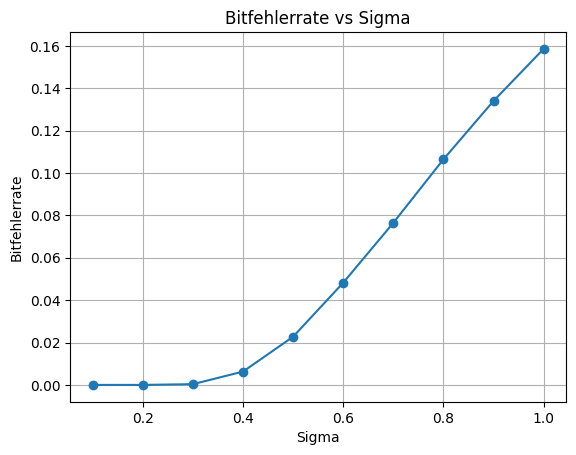

In [137]:
import numpy as np
import matplotlib.pyplot as plt


n = 10**5
sigma = 0.5
# Generate s and n for sigma=0.5
s = np.random.choice([-1, 1], n)
data = np.random.normal(0, sigma, n)
r = s + data
error = (r * s) < 0
ber_05 = np.mean(error)
print(f'Bitfehlerrate für σ=0.5: {ber_05:.6f}')

# fehlerrate von sigma für 0.1<= sigma <= 1.0
sigma_values = np.arange(0.1, 1.1, 0.1)
error_rates = []
for sig in sigma_values:
    s = np.random.choice([-1, 1], n)
    data = np.random.normal(0, sig, n)
    r = s + data
    error = (r * s) < 0
    error_rate = np.mean(error)
    error_rates.append(error_rate)
# plotten der Fehlerrate gegen sigma
plt.plot(sigma_values, error_rates, marker='o')
plt.xlabel('Sigma')
plt.ylabel('Bitfehlerrate')
plt.title('Bitfehlerrate vs Sigma')
plt.grid()
plt.show()

# Bauteiltoleranzen im Spannungsteiler
Gegeben ist ein Spannungsteiler

$$U_{\text{out}} = U_{\text{in}} \cdot \frac{R_2}{R_1 + R_2}.$$

Die Nennwerte seien

$$R_1 = 10\,\text{k}\Omega, \qquad R_2 = 5\,\text{k}\Omega. $$

Beide Widerstände haben eine Toleranz von $5\%$ und werden normalverteilt modelliert.

- Simulieren Sie 50000 Zufallswerte.
- Bestimmen Sie Mittelwert und Standardabweichung von $V_{\text{out}}$.
- Plotten Sie das Histogramm.
- Bestimmen Sie das 95\%-Konfidenzintervall.


95% Konfidenzintervall für den Mittelwert von Vout: [1.6672 V, 1.6686 V]
Mittelwert von Vout: 1.6679 V
Standardabweichung von Vout: 0.0787 V


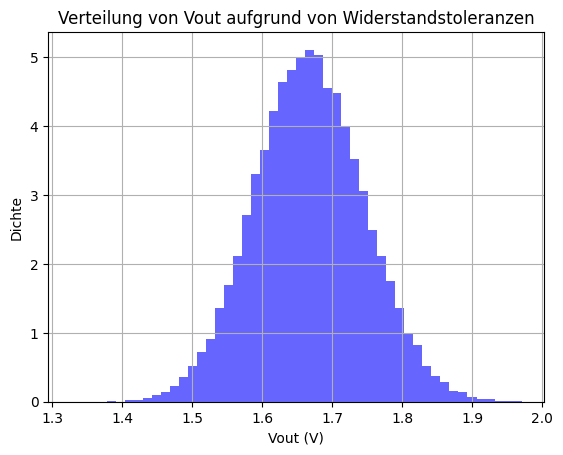

In [187]:
import numpy as np
import matplotlib.pyplot as plt

def Uout(R1, R2, Uin):
    return Uin * (R2 / (R1 + R2))

R1 = 10000
R2 = 5000
Uin = 5

n = 5 * (10**4)
toleranz = 0.05

r1_data = np.random.normal(R1, R1*toleranz, n)
r2_data = np.random.normal(R2, R2*toleranz, n)
v_out = Uout(r1_data, r2_data, Uin)
mean = np.mean(v_out)
std_dev = np.std(v_out)

ci_lower = mean - 1.96 * (std_dev / np.sqrt(n))
ci_upper = mean + 1.96 * (std_dev / np.sqrt(n))
print(f'95% Konfidenzintervall für den Mittelwert von Vout: [{ci_lower:.4f} V, {ci_upper:.4f} V]')


print(f'Mittelwert von Vout: {mean:.4f} V')
print(f'Standardabweichung von Vout: {std_dev:.4f} V')
plt.hist(v_out, bins=50, density=True, alpha=0.6, color='b')
plt.xlabel('Vout (V)')
plt.ylabel('Dichte')
plt.title('Verteilung von Vout aufgrund von Widerstandstoleranzen')
plt.grid()
plt.show()

# Jitter in einem Taktsignal
Der zeitliche Jitter eines Taktsignals werde modelliert durch

$$ t_{\text{real}} = t_{\text{ideal}} + \epsilon $$

mit

$$ \epsilon \sim \mathcal{N}(0,\sigma^2) \;\;\;\; \sigma = 20\,\text{ps}$$

Das System toleriert maximal eine Timingabweichung von $ 50\,\text{ps} $.

- Simulieren Sie $10^6$ Taktperioden.
- Bestimmen Sie die Wahrscheinlichkeit für einen Timingfehler.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lebensdauer eines elektronischen Bauteils (Exponentialverteilung)

Die Lebensdauer eines elektronischen Bauteils kann häufig durch eine Exponentialverteilung modelliert werden:

$$ T \sim \operatorname{Exp}(\lambda)$$

mit Ausfallrate

$$ \lambda = \frac{1}{\text{MTBF}}.$$

Ein Sensor habe eine mittlere Lebensdauer (Mean Time Between Failures)

$$ \text{MTBF} = 5000 \text{ Stunden}.$$


- Simulieren Sie $10^5$ Lebensdauern.
- Plotten Sie ein Histogramm der Lebensdauer.
- Bestimmen Sie Erwartungswert und Varianz aus der Simulation.
- Bestimmen Sie die Wahrscheinlichkeit, dass ein Bauteil länger als 8000 Stunden funktioniert.
- Bestimmen Sie die Wahrscheinlichkeit, dass ein Bauteil innerhalb der ersten 1000 Stunden ausfällt.


